# 静态断点
- 静态断点是在状态图编译或调用时设置的，因此不属于业务逻辑
- 静态断点不能接受调用者的信息，也不回给予反馈
- 如何设置静态断点：
    - 编译图时设置静态断点：`graph.compile(interrupt_before=['node1', 'node2'], interrupt_after=['node1', 'node2'])`。这种方式设置的静态断点复用同一个图时，多次仍然生效
    - 调用图时设置静态断点：`graph.invoke(interrupt_before=['node1', 'node2'], interrupt_after=['node1', 'node2'])`。这种方式优先级比compile时设置优先级更高，但只对本次调用生效, 图的表现形式就是一个没有interrupt的图，如果invoke时没有指定interrupt,就是按普通图一次性执行完
- 如何恢复静态断点：
    - 无论是那种方式设置的静态断点，都是通过`graph.invoke(None, config=config)`恢复断点。这里的入参一定是None,但第一次调用图时不能传None，否则会报错。
- 静态断点分两类：interrupt_before和interrupt_after：
    - interrupt_before在超步第一阶段计算完超步的任务列表后，节点任务开始执行前检查触发中断的条件：
        - 当前检查点状态和上一次静态断点或图初始状态产生了变化(目前验证只要有节点运行了，即便这些节点没有修改state，也会触发，看来是另外的东西)
        - 当前超步的任务列表和指定的interrupt_before存在交集
    - interrupt_after在超步第三阶段执行，当前超步任务全执行完毕，写入应用到通道并创建检查点之后进行检查：
        - 当前检查点状态和上一次静态断点或图初始状态产生了变化
        - 并且当前超步的任务列表和interrupt_after存在交集
- 静态断点发生在超步边界，而非节点边界，因此存在并行节点，且只有其中一个设置了静态断电时，会阻断所有并行节点的执行

## 编译时设置断点：串行阶段多断点
- 这里虽然node_a,node_b都有before和after中断，但是只会中断3次
- 因此node_a的after在中断时会保存检查点，恢复时修改状态，在node_b的before断点判断是否要触发时，会比较当前检查点状态和上一次静态断点相比，状态没有变化，就会不阻断，所以node_b的before断点不会阻断

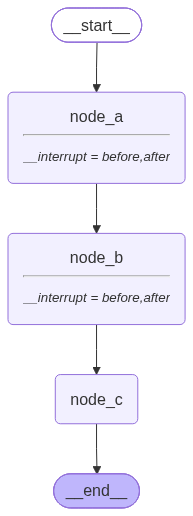

2026-08-16 13:54:25.874 | INFO     | __main__:<module>:51 - ==========-> 第一次执行 <-==========
2026-08-16 13:54:25.877 | INFO     | __main__:<module>:53 - 第一次执行结果：None
2026-08-16 13:54:25.879 | INFO     | __main__:<module>:55 - ==========-> 第二次执行 <-==========
2026-08-16 13:54:25.880 | INFO     | __main__:node_a:11 - node_a 被执行
2026-08-16 13:54:25.882 | INFO     | __main__:<module>:57 - 第二次执行结果：{'final_res': 'node_a 运行的中间结果'}
2026-08-16 13:54:25.883 | INFO     | __main__:<module>:59 - ==========-> 第三次执行 <-==========
2026-08-16 13:54:25.884 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-16 13:54:25.886 | INFO     | __main__:<module>:61 - 第三次执行结果：{'final_res': 'node_b 运行的中间结果'}
2026-08-16 13:54:25.887 | INFO     | __main__:<module>:63 - ==========-> 第四次执行 <-==========
2026-08-16 13:54:25.889 | INFO     | __main__:node_c:23 - node_c 被执行
2026-08-16 13:54:25.891 | INFO     | __main__:<module>:65 - 第四次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-08-16 13:54:25.892 | INFO     | __main__:<modul

In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke({}, config=config)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(None, config=config)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(None, config=config)
logger.info("第三次执行结果：{}", third_res)

logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
final_res = graph.invoke(None, config=config)
logger.info("第四次执行结果：{}", final_res)

logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)

## 并行节点部分节点设置静态断点

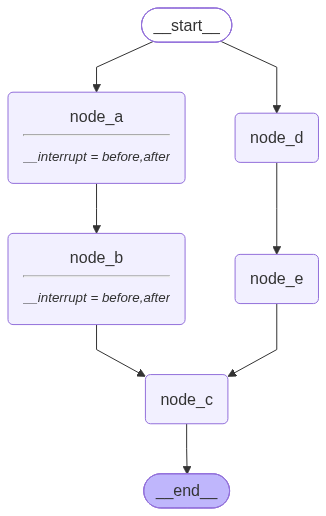

2026-08-14 10:13:21.507 | INFO     | __main__:<module>:62 - ==========-> 第一次执行 <-==========
2026-08-14 10:13:21.510 | INFO     | __main__:<module>:64 - 第一次执行结果：None
2026-08-14 10:13:21.511 | INFO     | __main__:<module>:66 - ==========-> 第二次执行 <-==========
2026-08-14 10:13:21.513 | INFO     | __main__:node_a:11 - node_a 被执行
2026-08-14 10:13:21.515 | INFO     | __main__:node_d:29 - node_d 被执行
2026-08-14 10:13:21.519 | INFO     | __main__:<module>:68 - 第二次执行结果：{'final_res': 'node_a 运行的中间结果'}
2026-08-14 10:13:21.520 | INFO     | __main__:<module>:70 - ==========-> 第三次执行 <-==========
2026-08-14 10:13:21.522 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-14 10:13:21.524 | INFO     | __main__:node_e:33 - node_e 被执行
2026-08-14 10:13:21.529 | INFO     | __main__:<module>:72 - 第三次执行结果：{'final_res': 'node_b 运行的中间结果'}
2026-08-14 10:13:21.529 | INFO     | __main__:<module>:74 - ==========-> 第四次执行 <-==========
2026-08-14 10:13:21.531 | INFO     | __main__:node_c:23 - node_c 被执行
2026-08-14 10:

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }

def node_d(state: OverAllState) -> OverAllState:
    logger.info("node_d 被执行")
    return {}

def node_e(state: OverAllState) -> OverAllState:
    logger.info("node_e 被执行")
    return {}

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge(START, "node_d")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_d", "node_e")
builder.add_edge(["node_b", "node_e"], "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke({}, config=config)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(None, config=config)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(None, config=config)
logger.info("第三次执行结果：{}", third_res)

logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
final_res = graph.invoke(None, config=config)
logger.info("第四次执行结果：{}", final_res)

logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)

## 调用时设置断点

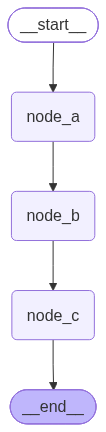

2026-08-14 10:18:09.225 | INFO     | __main__:<module>:49 - ==========-> 第一次执行 <-==========
2026-08-14 10:18:09.228 | INFO     | __main__:<module>:56 - 第一次执行结果：None
2026-08-14 10:18:09.229 | INFO     | __main__:<module>:58 - ==========-> 第二次执行 <-==========
2026-08-14 10:18:09.230 | INFO     | __main__:node_a:11 - node_a 被执行
2026-08-14 10:18:09.232 | INFO     | __main__:<module>:65 - 第二次执行结果：{'final_res': 'node_a 运行的中间结果'}
2026-08-14 10:18:09.233 | INFO     | __main__:<module>:67 - ==========-> 第三次执行 <-==========
2026-08-14 10:18:09.235 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-14 10:18:09.237 | INFO     | __main__:<module>:74 - 第三次执行结果：{'final_res': 'node_b 运行的中间结果'}
2026-08-14 10:18:09.237 | INFO     | __main__:<module>:76 - ==========-> 第四次执行 <-==========
2026-08-14 10:18:09.238 | INFO     | __main__:node_c:23 - node_c 被执行
2026-08-14 10:18:09.240 | INFO     | __main__:<module>:83 - 第四次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-08-14 10:18:09.241 | INFO     | __main__:<modul

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer
)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke(
    {},
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(
    None,
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(
    None,
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第三次执行结果：{}", third_res)

logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
final_res = graph.invoke(
    None,
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第四次执行结果：{}", final_res)

logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)

## 调用时设置断点错误示例
- 正确应当每次invoke都传入interrupt_before和interrupt_after

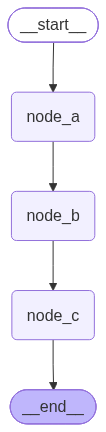

2026-08-14 10:25:46.111 | INFO     | __main__:<module>:49 - ==========-> 第一次执行 <-==========
2026-08-14 10:25:46.113 | INFO     | __main__:<module>:56 - 第一次执行结果：None
2026-08-14 10:25:46.115 | INFO     | __main__:<module>:58 - ==========-> 第二次执行 <-==========
2026-08-14 10:25:46.116 | INFO     | __main__:node_a:11 - node_a 被执行
2026-08-14 10:25:46.118 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-14 10:25:46.120 | INFO     | __main__:node_c:23 - node_c 被执行
2026-08-14 10:25:46.122 | INFO     | __main__:<module>:63 - 第二次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-08-14 10:25:46.123 | INFO     | __main__:<module>:65 - ==========-> 第三次执行 <-==========
2026-08-14 10:25:46.124 | INFO     | __main__:<module>:70 - 第三次执行结果：{'final_res': 'node_c 运行的中间结果'}


In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer
)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke(
    {},
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(
    None,
    config=config,
)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(
    None,
    config=config,
)
logger.info("第三次执行结果：{}", third_res)
#
# logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
# final_res = graph.invoke(
#     None,
#     config=config,
# )
# logger.info("第四次执行结果：{}", final_res)
#
# logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)

## 验证：节点未改变状态时，interrupt_before 不触发
- node_a 不修改状态（返回 {}），node_b 设置了 interrupt_before
- 预期：node_a 执行后状态未变化 → node_b 的 before 断点不触发 → node_b 直接执行
- 对比：node_a 修改了状态 → node_b 的 before 断点触发 → 中断等待恢复

In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

# ============ 场景1：node_a 不修改状态 ============
def node_a_no_change(state: OverAllState) -> OverAllState:
    logger.info("node_a（不改状态）被执行")
    return {}  # 不修改任何状态

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {}

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {"final_res": "node_c 的结果"}

builder1 = StateGraph(state_schema=OverAllState)
builder1.add_node("node_a", node_a_no_change)
builder1.add_node("node_b", node_b)
builder1.add_node("node_c", node_c)
builder1.add_edge(START, "node_a")
builder1.add_edge("node_a", "node_b")
builder1.add_edge("node_b", "node_c")
builder1.add_edge("node_c", END)

checkpointer1 = InMemorySaver()
graph1 = builder1.compile(
    checkpointer=checkpointer1,
    interrupt_before=["node_b", "node_c"],
)

config1 = {"configurable": {"thread_id": "no_change"}}
logger.info("=" * 50)
logger.info("场景1：node_a 不修改状态")
logger.info("=" * 50)
#
res1 = graph1.invoke({}, config=config1)
logger.info("第1次结果：{}", res1)

res1 = graph1.invoke(None, config=config1)
logger.info("第2次结果：{}", res1)

# res1 = graph1.invoke(None, config=config1)
# logger.info("第3次结果：{}", res1)

# 检查是否有中断
state1 = graph1.get_state(config=config1)
logger.info("next（下一步要执行的节点）：{}", state1.next)
logger.info("是否有 pending 中断：{}", state1.interrupts)

if state1.next == ():
    logger.info("✅ 验证通过")
else:
    logger.info("❌ 验证失败：图停在了 {}，说明断点触发了", state1.next)

2026-08-16 13:57:19.142 | INFO     | __main__:<module>:40 - ==================================================
2026-08-16 13:57:19.143 | INFO     | __main__:<module>:41 - 场景1：node_a 不修改状态
2026-08-16 13:57:19.144 | INFO     | __main__:<module>:42 - ==================================================
2026-08-16 13:57:19.147 | INFO     | __main__:node_a_no_change:13 - node_a（不改状态）被执行
2026-08-16 13:57:19.149 | INFO     | __main__:<module>:45 - 第1次结果：None
2026-08-16 13:57:19.151 | INFO     | __main__:node_b:17 - node_b 被执行
2026-08-16 13:57:19.153 | INFO     | __main__:<module>:48 - 第2次结果：{}
2026-08-16 13:57:19.154 | INFO     | __main__:<module>:55 - next（下一步要执行的节点）：('node_c',)
2026-08-16 13:57:19.155 | INFO     | __main__:<module>:56 - 是否有 pending 中断：()
2026-08-16 13:57:19.156 | INFO     | __main__:<module>:61 - ❌ 验证失败：图停在了 ('node_c',)，说明断点触发了


### 对比：node_a 修改了状态 → interrupt_before 触发

In [ ]:
# ============ 场景2：node_a 修改了状态 ============
def node_a_with_change(state: OverAllState) -> OverAllState:
    logger.info("node_a（修改状态）被执行")
    return {"final_res": "node_a 修改了状态"}  # 修改了状态

builder2 = StateGraph(state_schema=OverAllState)
builder2.add_node("node_a", node_a_with_change)
builder2.add_node("node_b", node_b)
builder2.add_node("node_c", node_c)
builder2.add_edge(START, "node_a")
builder2.add_edge("node_a", "node_b")
builder2.add_edge("node_b", "node_c")
builder2.add_edge("node_c", END)

checkpointer2 = InMemorySaver()
graph2 = builder2.compile(
    checkpointer=checkpointer2,
    interrupt_before=["node_b"],  # 同样在 node_b 前设置断点
)

config2 = {"configurable": {"thread_id": "with_change"}}
logger.info("=" * 50)
logger.info("场景2：node_a 修改了状态")
logger.info("=" * 50)

res2 = graph2.invoke({}, config=config2)
logger.info("结果：{}", res2)

# 检查是否有中断
state2 = graph2.get_state(config=config2)
logger.info("next（下一步要执行的节点）：{}", state2.next)
logger.info("是否有 pending 中断：{}", state2.interrupts)

if state2.next == ():
    logger.info("图已执行完毕（不应该走到这里）")
else:
    logger.info("✅ 验证通过：node_a 修改了状态 → node_b 的 before 断点触发 → 图停在 {}", state2.next)

# 恢复执行
logger.info("=" * 50)
logger.info("恢复执行...")
logger.info("=" * 50)
res2_resume = graph2.invoke(None, config=config2)
logger.info("最终结果：{}", res2_resume)